In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as st
from scipy.stats import binom
import seaborn as sns

#### Шаг 1. Загрузка данных

##### Считаем данные из csv-файла в датафрейм и сохраните в переменные:

In [4]:
try:
    users_go = pd.read_csv('/datasets/users_go.csv')
except:
    users_go = pd.read_csv('https://code.s3.yandex.net/datasets/users_go.csv')
try:
    rides_go = pd.read_csv('/datasets/rides_go.csv')
except:
    rides_go = pd.read_csv('https://code.s3.yandex.net/datasets/rides_go.csv')
try:
    subscriptions_go = pd.read_csv('/datasets/subscriptions_go.csv')
except:
    subscriptions_go = pd.read_csv('https://code.s3.yandex.net/datasets/subscriptions_go.csv')

##### Выведем первые 5 строк и основную информацию о датафреймах:

In [6]:
users_go.head(5)

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


In [7]:
users_go.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB


In [8]:
rides_go.head(5)

,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


In [9]:
rides_go.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB


In [10]:
subscriptions_go.head(5)

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


In [11]:
subscriptions_go.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 196.0+ bytes


**В данном пункте были загружены датафреймы и выведена основная информация о них:**
- Столбцы названы корректно
- Тип данных в столбце `date` датафрейма `rides_go` изменен при считывании данных
- Пропусков нет

#### Шаг 2. Предобработка данных

##### Приведем столбец `date` датафрейма `rides_go` к типу даты pandas:

In [15]:
rides_go['date'] = pd.to_datetime(rides_go['date'], format='%Y-%m-%d').dt.round('1D')

In [16]:
rides_go.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   18068 non-null  int64         
 1   distance  18068 non-null  float64       
 2   duration  18068 non-null  float64       
 3   date      18068 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 564.8 KB


##### Создадим новый столбец с номером месяца на основе столбца `date`:

In [18]:
rides_go['month'] = rides_go['date'].dt.month

In [19]:
rides_go.head(5)

,user_id,distance,duration,date,month
0,1,4409.919140,25.599769,2021-01-01,1
1,1,2617.592153,15.816871,2021-01-18,1
2,1,754.159807,6.232113,2021-04-20,4
3,1,2694.783254,18.511000,2021-08-11,8
4,1,4028.687306,26.265803,2021-08-28,8


##### Проверим датафреймы на наличие пропусков

In [21]:
users_go.isna().sum()

user_id              0
name                 0
age                  0
city                 0
subscription_type    0
dtype: int64

In [22]:
rides_go.isna().sum()

user_id     0
distance    0
duration    0
date        0
month       0
dtype: int64

In [23]:
subscriptions_go.isna().sum()

subscription_type    0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64

Пропусков нет, изменять типы данных не требуется.

Проверим за какой период представлены данные в датафрейме `rides_go`:

In [26]:
print(rides_go['date'].max())
print(rides_go['date'].min())
print(rides_go['date'].max() - rides_go['date'].min())

2021-12-30 00:00:00
2021-01-01 00:00:00
363 days 00:00:00


Данные представлены за 2021 год с разницей между максимумом и минимумом в 363 дня.

Округлим расстояния в `rides_go['distance']`:

In [28]:
rides_go = rides_go.round({'distance':0})
rides_go['distance'] = rides_go['distance'].astype('int64')
rides_go.head(5)

,user_id,distance,duration,date,month
0,1,4410,25.599769,2021-01-01,1
1,1,2618,15.816871,2021-01-18,1
2,1,754,6.232113,2021-04-20,4
3,1,2695,18.511000,2021-08-11,8
4,1,4029,26.265803,2021-08-28,8


Проверим датафреймы на наличие явных дубликатов:

In [30]:
rides_go.duplicated().sum()

0

In [31]:
subscriptions_go.duplicated().sum()

0

In [32]:
users_go.duplicated().sum()

31

In [33]:
users_go.shape

(1565, 5)

Удалим явные дубликаты из датафрейма `users_go`:

In [35]:
users_go.drop_duplicates(inplace=True)
users_go.shape

(1534, 5)

Дубликаты удалены корректно: 1565 - 31 = 1534.

**В данном пункте была произведена предобработка данных:**
- Создан столбец с номерами месяцев
- Датафреймы проверены на наличие пропусков
- Проверено за какой период представлены данные в датафрейме `rides_go`
- Округлены расстояния в датафрейме `rides_go['distance']`
- Датафреймы проверены на наличие явных дубликатов и они удалены из датафрейма `users_go`

#### Шаг 3. Исследовательский анализ данных

##### Частота встречаемости городов

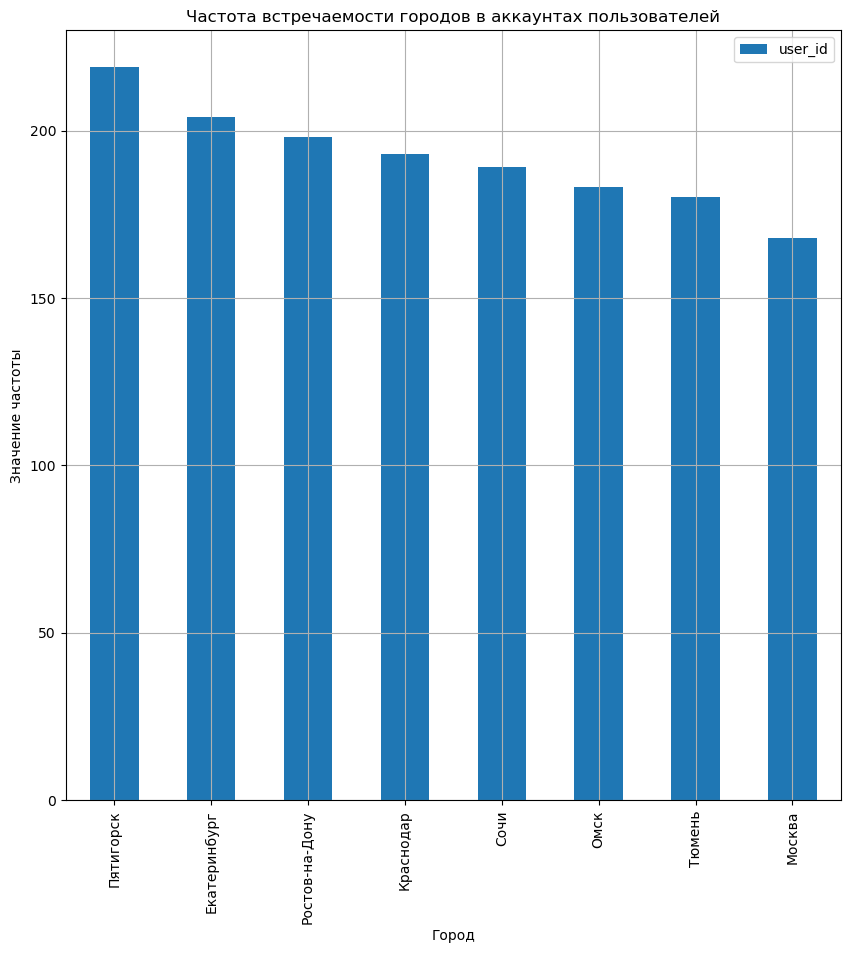

In [40]:
city_stat = users_go.pivot_table(index='city', values='user_id', aggfunc='count').sort_values(by=('user_id'), ascending=False)
city_stat.plot(kind='bar', grid=True, figsize=(10, 10))
plt.title('Частота встречаемости городов в аккаунтах пользователей')
plt.xlabel("Город")
plt.ylabel("Значение частоты")
plt.show()

In [41]:
city_stat

,user_id
city,
Пятигорск,219
Екатеринбург,204
Ростов-на-Дону,198
Краснодар,193
Сочи,189
Омск,183
Тюмень,180
Москва,168


Больше всего пользователей из Пятигорска, меньше всего - из Москвы.

Теперь посмотрим в каких городах совершается больше всего поездок:

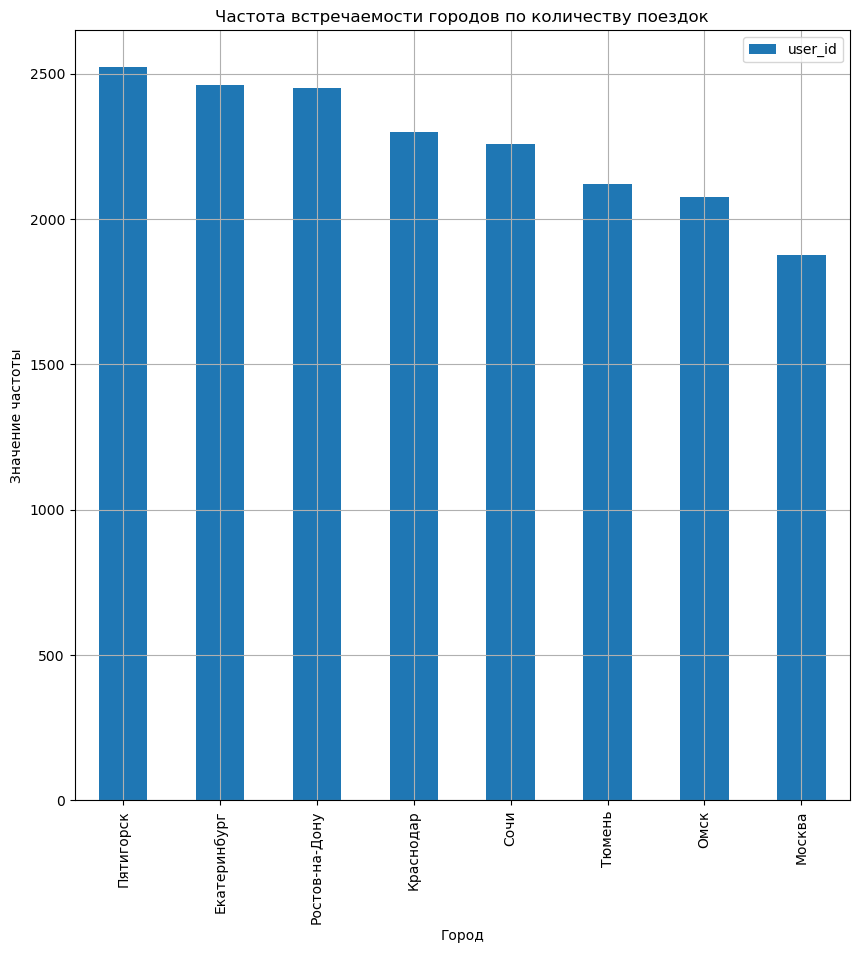

In [44]:
city_stat = rides_go.merge(users_go, how='left').pivot_table(index='city', values='user_id', aggfunc='count').sort_values(by=('user_id'), ascending=False)
city_stat.plot(kind='bar', grid=True, figsize=(10, 10))
plt.title('Частота встречаемости городов по количеству поездок')
plt.xlabel("Город")
plt.ylabel("Значение частоты")
plt.show()

In [45]:
city_stat

,user_id
city,
Пятигорск,2524
Екатеринбург,2461
Ростов-на-Дону,2450
Краснодар,2301
Сочи,2259
Тюмень,2121
Омск,2077
Москва,1875


Распределение практически аналогично предыдущему: Ростов-на-Дону поменялся местами с Екатеринбургом, а Тюмень с Омском.

##### Соотношение пользователей с подпиской и без подписки

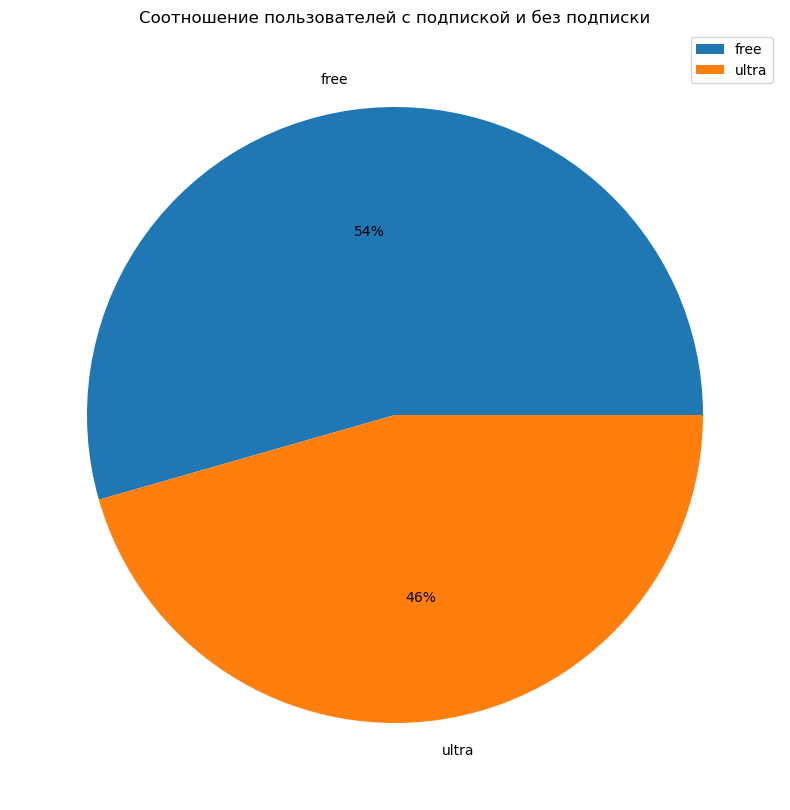

In [48]:
subscription_type_count = users_go.pivot_table(index='subscription_type', values='user_id', aggfunc='count')
subscription_type_count.plot(kind='pie', y='user_id', autopct='%1.0f%%', figsize=(10, 10))
plt.title('Соотношение пользователей с подпиской и без подписки')
plt.ylabel("")
plt.show()

Практически у половины пользователей (46%) есть подписка.

##### Возраст пользователей

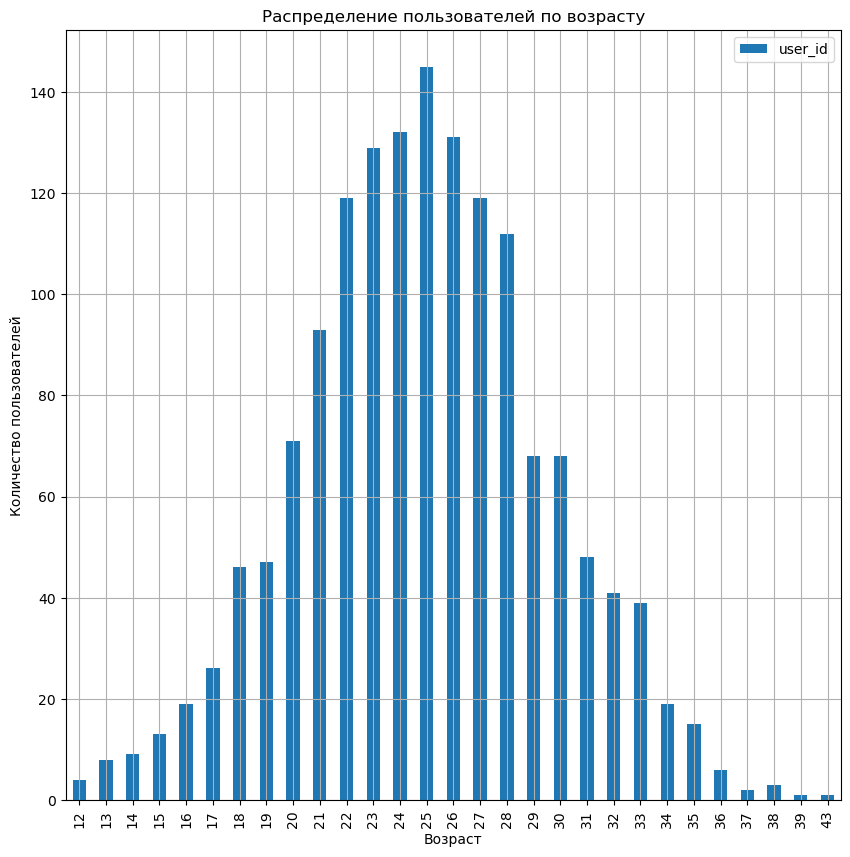

In [51]:
age_count = users_go.pivot_table(index='age', values='user_id', aggfunc='count')
age_count.plot(kind='bar', grid=True, figsize=(10, 10))
plt.title('Распределение пользователей по возрасту')
plt.xlabel("Возраст")
plt.ylabel("Количество пользователей")
plt.show()

In [52]:
users_go['age'].describe()

count    1534.000000
mean       24.903520
std         4.572367
min        12.000000
25%        22.000000
50%        25.000000
75%        28.000000
max        43.000000
Name: age, dtype: float64

Распределение пользователей по возрасту имеет форму близкую к нормальному распределению со средним значением 25 лет, 75% пользователей младше 28 лет и 25% пользователей младше 22 лет.

##### Расстояние, которое пользователь преодолел за одну поездку

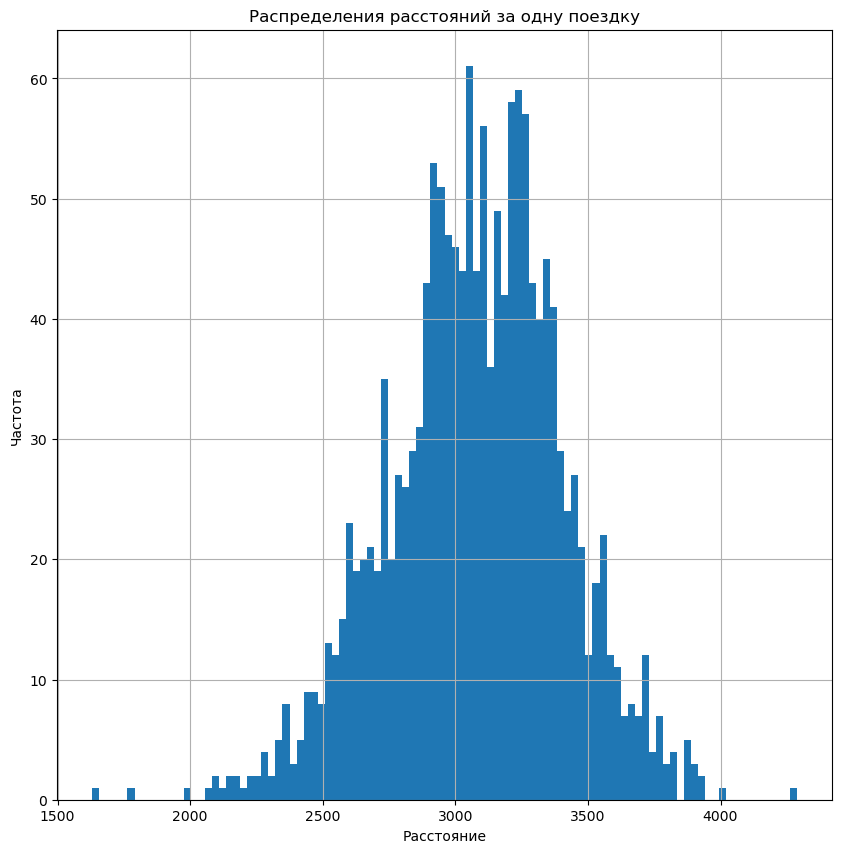

In [55]:
distance_count = rides_go.pivot_table(index='user_id', values='distance')
distance_count.hist(bins=100, figsize=(10, 10))
plt.title('Распределения расстояний за одну поездку')
plt.xlabel("Расстояние")
plt.ylabel("Частота")
plt.show()

In [56]:
rides_go['distance'].describe()

count    18068.000000
mean      3070.659010
std       1116.832209
min          1.000000
25%       2543.000000
50%       3134.000000
75%       3776.000000
max       7211.000000
Name: distance, dtype: float64

Большинство пользователей в среднем за поездку проезжают от 2,8 до 3,3 км, 75% поездок меньше 3,776 км. Так же есть небольшое число выбросов со значениями меньше 2 км и больше 4 км. Форма распределения близка к нормальному.

##### Продолжительность поездки

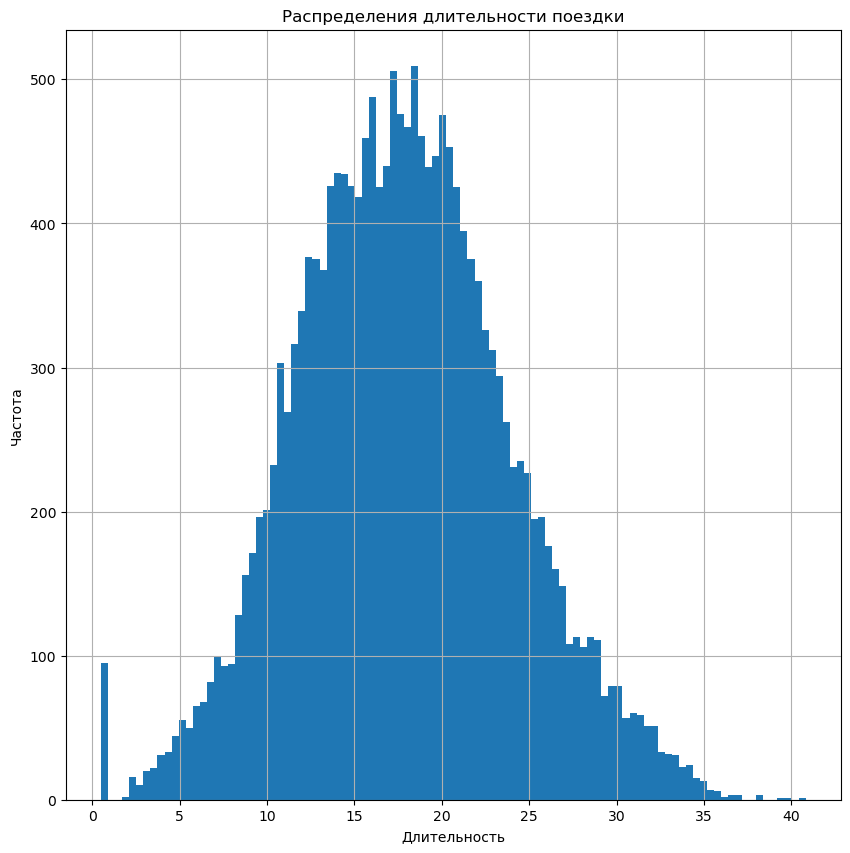

In [59]:
rides_go['duration'].hist(bins=100, figsize=(10, 10))
plt.title('Распределения длительности поездки')
plt.xlabel("Длительность")
plt.ylabel("Частота")
plt.show()

In [60]:
rides_go['duration'].describe()

count    18068.000000
mean        17.805011
std          6.091051
min          0.500000
25%         13.597563
50%         17.678395
75%         21.724800
max         40.823963
Name: duration, dtype: float64

Большинство пользователей совершают поездку за время от 10 до 25 минут, 77% поездок укладываются в 22 минуты. Так же есть выброс в районе одной минуты. Форма распределения близка к нормальному.

**В данном пункте был произведен исследовательский анализ данных:**
- Больше всего пользователей из Пятигорска, меньше всего - из Москвы
- Практически у половины пользователей (46%) есть подписка
- Распределение пользователей по возрасту имеет форму близкую к нормальному распределению со средним значением 25 лет, 75% пользователей младше 28 лет и 25% пользователей младше 22 лет
- Большинство пользователей в среднем за поездку проезжают от 2.8 до 3.3 км, 75% поездок меньше 3.776 км
- Большинство пользователей совершают поездку за время от 10 до 25 минут, 77% поездок укладываются в 22 минуты

#### Шаг 4. Объединение данных

##### Объединим данные о пользователях, поездках и подписках в один датафрейм

Проверим размерность датасетов:

In [66]:
print('Размерность датасета users_go:', users_go.shape)
print('Размерность датасета rides_go:', rides_go.shape)
print('Размерность датасета subscriptions_go:', subscriptions_go.shape)

Размерность датасета users_go: (1534, 5)
Размерность датасета rides_go: (18068, 5)
Размерность датасета subscriptions_go: (2, 4)


Таким образом, при объединении датасетов мы должны получить датасет размерностью (18068, 12). 18068 - количество столбцов в самом большом датасете. 12 = 5 + 5 + 4 - 2, так так 2 раза будет происходить объединение по разным столбцам.

In [68]:
data = rides_go.merge(users_go)
data = data.merge(subscriptions_go)
data.head(5)

,user_id,distance,duration,date,month,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee
0,1,4410,25.599769,2021-01-01,1,Кира,22,Тюмень,ultra,6,0,199
1,1,2618,15.816871,2021-01-18,1,Кира,22,Тюмень,ultra,6,0,199
2,1,754,6.232113,2021-04-20,4,Кира,22,Тюмень,ultra,6,0,199
3,1,2695,18.511000,2021-08-11,8,Кира,22,Тюмень,ultra,6,0,199
4,1,4029,26.265803,2021-08-28,8,Кира,22,Тюмень,ultra,6,0,199


In [69]:
data.shape

(18068, 12)

Размернось правильная.

Проверим на пропуски объединенный датасет:

In [71]:
data.isna().sum()

user_id              0
distance             0
duration             0
date                 0
month                0
name                 0
age                  0
city                 0
subscription_type    0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64

Пропусков нет.

##### Создадим отдельные датафреймы с данными о пользователях с подпиской и без

In [74]:
data_ultra = data.loc[data['subscription_type'] == 'ultra']
data_free = data.loc[data['subscription_type'] == 'free']

##### Изучим информацию о расстоянии и времени поездок для обеих категорий

###### Распределение расстояний за одну поездку

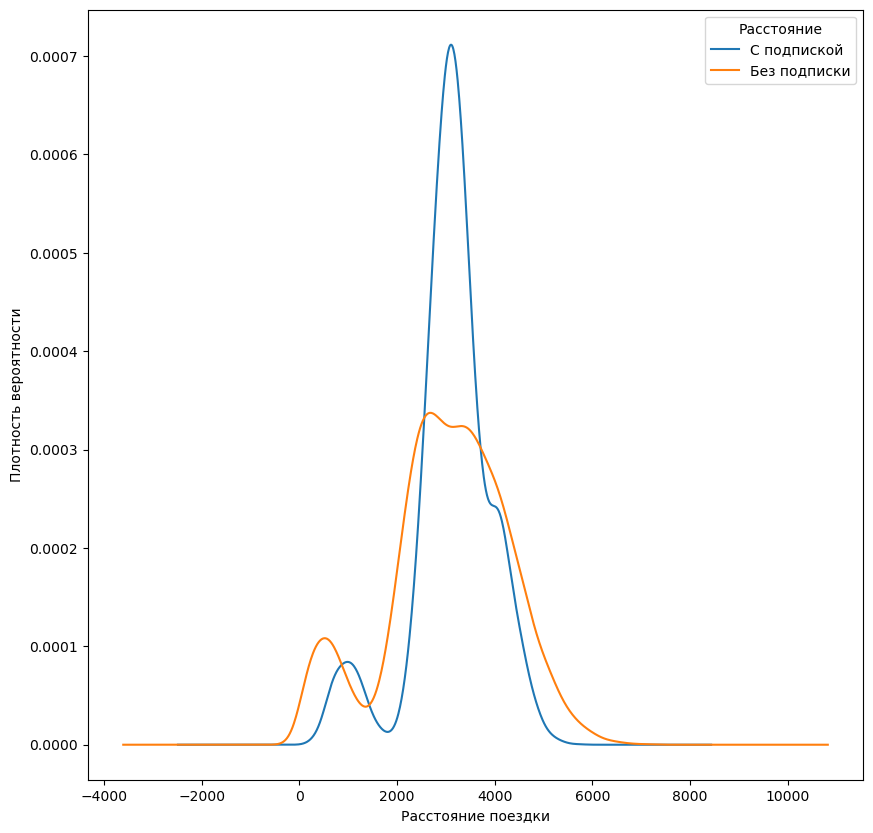

In [77]:
data_ultra['distance'].plot(kind='kde', figsize=(10, 10))
data_free['distance'].plot(kind='kde', figsize=(10, 10))
plt.legend(['С подпиской', 'Без подписки'], title='Расстояние')
plt.xlabel("Расстояние поездки")
plt.ylabel("Плотность вероятности")
plt.show()

Распределения расстояний имеют похожую форму, однако, обратим внимание, у пользователей с подпиской более выражено среднее значение в 3 км и меньший разброс вокруг него.

###### Распределение длительностей поездок

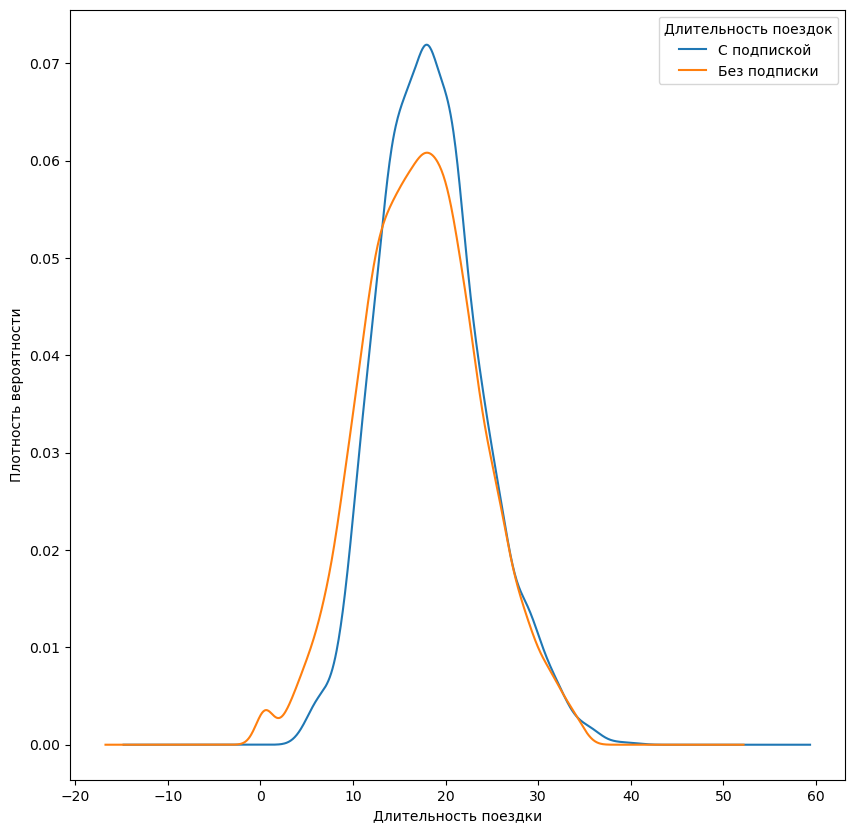

In [80]:
data_ultra['duration'].plot(kind='kde', figsize=(10, 10))
data_free['duration'].plot(kind='kde', figsize=(10, 10))
plt.legend(['С подпиской', 'Без подписки'], title='Длительность поездок')
plt.xlabel("Длительность поездки")
plt.ylabel("Плотность вероятности")
plt.show()

Распределения практически эдентичны.

**В данном пункте было произведено объединение данных:**
- Объединины данные о пользователях, поездках и подписках в один датафрейм
- Созданы датафреймы для пользователей с информацией о пользователях с подпиской и без
- Изучены данные о длительности и расстоянии поездок
- У пользователей с подпиской более выражено среднее значение в 3 км и меньший разброс вокруг него
- Длительность времени распределена практически одинаково у пользователей с подпиской и без

#### Шаг 5. Подсчёт выручки

Создадим датафрейм с агрегированными данными о поездках на основе датафреймов с объединёнными данными о пользователях с подпиской и без:

In [85]:
data_ultra_pivot = data_ultra.pivot_table(index=['user_id', 'month'], values=['distance', 'duration'], aggfunc={'distance': ['sum', 'count'], 'duration': 'sum'})
data_ultra_pivot['duration'] = np.ceil(data_ultra_pivot['duration'])
data_free_pivot = data_free.pivot_table(index=['user_id', 'month'], values=['distance', 'duration'], aggfunc={'distance': ['sum', 'count'], 'duration': 'sum'})
data_free_pivot['duration'] = np.ceil(data_free_pivot['duration'])

Посчитаем выручку:

In [87]:
data_ultra_pivot['earning'] = subscriptions_go['minute_price'].iloc[1] * data_ultra_pivot['duration']['sum'] + subscriptions_go['subscription_fee'].iloc[1]
data_free_pivot['earning'] = subscriptions_go['minute_price'].iloc[0] * data_free_pivot['duration']['sum'] + subscriptions_go['start_ride_price'].iloc[0] * data_free_pivot['distance']['count']

Объединим эти датафреймы:

In [89]:
data_ultra_pivot['subscription_type'] = 'ultra'
data_free_pivot['subscription_type'] = 'free'
data_pivot = pd.concat([data_ultra_pivot, data_free_pivot])

Проверим размерности датафреймов:

In [91]:
print('Размерность датасета data_ultra_pivot:', data_ultra_pivot.shape)
print('Размерность датасета data_free_pivot:', data_free_pivot.shape)
print('Размерность датасета data_pivot:', data_pivot.shape)

Размерность датасета data_ultra_pivot: (4533, 5)
Размерность датасета data_free_pivot: (6798, 5)
Размерность датасета data_pivot: (11331, 5)


In [92]:
data_ultra_pivot.shape[0] + data_free_pivot.shape[0] == data_pivot.shape[0]

True

Размерность правильная.

In [94]:
data_pivot.head(10)

distance        duration earning subscription_type
                 count    sum      sum                          
user_id month                                                   
1       1            2   7028     42.0   451.0             ultra
        4            1    754      7.0   241.0             ultra
        8            2   6724     45.0   469.0             ultra
        10           2   5810     32.0   391.0             ultra
        11           3   7004     54.0   523.0             ultra
        12           2   6752     28.0   367.0             ultra
2       3            3  10188     61.0   565.0             ultra
        4            2   6165     40.0   439.0             ultra
        6            1   3255     14.0   283.0             ultra
        7            2   6781     47.0   481.0             ultra

Рассчитаем выручку по типу подписки:

In [96]:
data_pivot.groupby(by=['subscription_type', 'month'])['earning'].sum()

subscription_type  month
free               1        192362.0
                   2        164504.0
                   3        185638.0
                   4        183934.0
                   5        186334.0
                   6        190488.0
                   7        183558.0
                   8        185404.0
                   9        192100.0
                   10       179732.0
                   11       177604.0
                   12       193422.0
ultra              1        143502.0
                   2        124266.0
                   3        142074.0
                   4        136826.0
                   5        148647.0
                   6        143342.0
                   7        142896.0
                   8        138096.0
                   9        128863.0
                   10       133446.0
                   11       126096.0
                   12       130543.0
Name: earning, dtype: float64

Визуализируем распределение выручки:

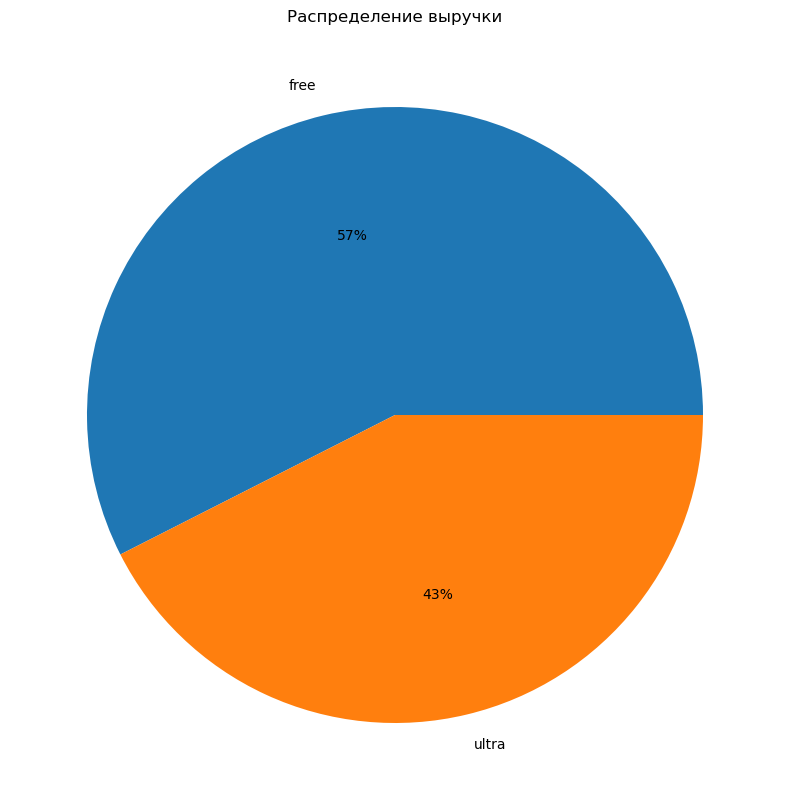

In [98]:
fig = plt.figure(figsize=(10, 10))
plt.pie(data_pivot.groupby(by='subscription_type')['earning'].sum(), labels=['free', 'ultra'], autopct='%1.0f%%')
plt.title('Распределение выручки')
plt.show()

Таким образом, 46% клиентов с подпиской `ultra` приносят 43% выручки.

**В данном пункте был произведен расчет выручки:**
- Подсчитана помесячная выручка для каждого пользователя
- Определена доля пользователей с разными типами подписок в выручке. Доля клентов с подпиской `ultra` составляет 46%

#### Шаг 6. Проверка гипотез

##### Проверим гипотезу о том, что пользователи с подпиской тратят больше времени на поездки:

Сформулируем нулевую и альтернативную гипотезы:
- Н0 - Пользователи с подпиской и без тратят одинаковое количество времени на поездку
- Н1 - Пользователи с подпиской тратят больше времени на поездку, чем пользователи без подписки (правосторонняя).

Имеем две независимые выборки, поэтому проведем двухвыборочный t-тест для независимых выборок:

In [104]:
print('Среднее выборки пользователей с подпиской:', data.loc[data['subscription_type'] == 'ultra']['duration'].mean().round(2))
print('Среднее выборки пользователей без подписки:', data.loc[data['subscription_type'] == 'free']['duration'].mean().round(2))
alpha = .05 #в задании не было задано, поэтому примем 0.05
results = st.ttest_ind(
    data.loc[data['subscription_type'] == 'ultra']['duration'],
    data.loc[data['subscription_type'] == 'free']['duration'],
    alternative='greater')
print('p-значение', results.pvalue)
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу')

Среднее выборки пользователей с подпиской: 18.54
Среднее выборки пользователей без подписки: 17.39
p-значение 1.2804098316645618e-34
Отвергаем нулевую гипотезу


Таким, образом, мы можем отвергнуть нулевую гипотезу о равенстве времени поездок пользователей с подпиской и без в пользу гипотезы о том, что пользователи с подпиской тратят больше времени на поездку, чем пользователи без подписки.

##### Расстояние одной поездки в 3130 метров — оптимальное с точки зрения износа самоката. Можно ли сказать, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров?  Проверим данную гипотезу:

Сформулируем нулевую и альтернативную гипотезы:
- Н0 - Среднее расстояние одной поездки подписчика равно 3130 метров
- Н1 - Среднее расстояние одной поездки подписчика больше 3130 метров (правосторонняя).

Имеем одну выборку, поэтому проведем одновыборочный t-тест о равенстве среднего генеральной совокупности числу:

In [108]:
print('Среднее выборки:', data.loc[data['subscription_type'] == 'ultra']['distance'].mean().round(2))
alpha = .05 #в задании не было задано, поэтому примем 0.05
value = 3130
results = st.ttest_1samp(
    data.loc[data['subscription_type'] == 'ultra']['distance'],
    value,
    alternative = 'greater')
print('p-значение', results.pvalue)
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу')

Среднее выборки: 3115.44
p-значение 0.9195649894697724
Не отвергаем нулевую гипотезу


Таким, образом, мы не можем отвергнуть нулевую гипотезу о равенстве среднего времени поездки пользователей с подпиской 3130 метрам.

##### Проверим гипотезу о том, будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки:

Изменим датафреймы датафреймы с данными о пользователях с подпиской и без:

In [112]:
data_ultra_pivot.reset_index(inplace=True)
data_free_pivot.reset_index(inplace=True)

Сформулируем нулевую и альтернативную гипотезы:
- Н0 - Помесячная выручка от пользователей с подпиской и без не отличается
- Н1 - Помесячная выручка от пользователей с подпиской больше, чем от пользователей без подписки (правосторонняя).

Имеем две независимые выборки, поэтому проведем двухвыборочный t-тест для независимых выборок:

In [114]:
print('Среднее выборки пользователей с подпиской:', data_pivot.loc[data_pivot['subscription_type'] == 'ultra']['earning'].mean().round(2))
print('Среднее выборки пользователей без подписки:', data_pivot.loc[data_pivot['subscription_type'] == 'free']['earning'].mean().round(2))
alpha = .05 #в задании не было задано, поэтому примем 0.05
results = st.ttest_ind(
    data_pivot.loc[data_pivot['subscription_type'] == 'ultra']['earning'],
    data_pivot.loc[data_pivot['subscription_type'] == 'free']['earning'],
    alternative='greater')
print('p-значение', results.pvalue)
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу')

Среднее выборки пользователей с подпиской: 361.48
Среднее выборки пользователей без подписки: 325.84
p-значение 2.8130926188487286e-35
Отвергаем нулевую гипотезу


Таким образом, мы можем отвергнуть нулевую гипотезу о равенстве помесячной выручки от пользователей с подпиской и без нее в пользу гипотезы о том, что помесячная выручка от пользователей с подпиской больше, чем от пользователей без подписки.

##### Представим такую ситуацию: техническая команда сервиса обновила сервера, с которыми взаимодействует мобильное приложение. Она надеется, что из-за этого количество обращений в техподдержку значимо снизилось. Некоторый файл содержит для каждого пользователя данные о количестве обращений до обновления и после него.

В данной ситуации необходимо применить двухвыборочный t-тест для зависимых выборок. В качестве выборок могло выступить распределение обращений по `used_id` до обновления сервера и после. Необходимо произвести левосторонний тест со следующими гипотезами:
- Н0 Количество обращений не изменилось
- Н1 Количество обращений уменьшилось (левосторонняя).

**В данном пункте были проверены ряд гипотез:**
- Отвергнута гипотеза о равенстве времени поездок пользователей с подпиской и без в пользу гипотезы о том, что пользователи с подпиской тратят больше времени на поездку, чем пользователи без подписки
- Не была отвергнута нулевая гипотеза о равенстве среднего времени поездки пользователей с подпиской 3130 метрам
- Отвергнута нулевая гипотеза о равенстве помесячной выручки от пользователей с подпиской и без нее в пользу гипотезы о том, что помесячная выручка от пользователей с подпиской больше, чем от пользователей без подписки.

#### Шаг 7. Распределения

##### Отделу маркетинга GoFast поставили задачу: нужно провести акцию с раздачей промокодов на один бесплатный месяц подписки, в рамках которой как минимум 100 существующих клиентов должны продлить эту подписку. То есть по завершении периода действия подписки пользователь может либо отказаться от неё, либо продлить, совершив соответствующий платёж. Эта акция уже проводилась ранее и по итогу выяснилось, что после бесплатного пробного периода подписку продлевают 10% пользователей. Выясним, какое минимальное количество промокодов нужно разослать, чтобы вероятность не выполнить план была примерно 5%.

Создадим биномиальное распределение и будем увеличивать число опытов до тех пор, пока вероятность 100 положительных исходов не снизится до 5%:

In [122]:
i = 100
distr = binom(n=i, p=.1)
while distr.cdf(100) > 0.05:
    distr = binom(n=i, p=.1)
    i += 1
print('N =', i)
print('Вероятность того, что подписку продлят менее 100 пользователей', distr.cdf(100).round(4))

N = 1173
Вероятность того, что подписку продлят менее 100 пользователей 0.0495


Построим график распределения:

C:\Users\Gleb\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


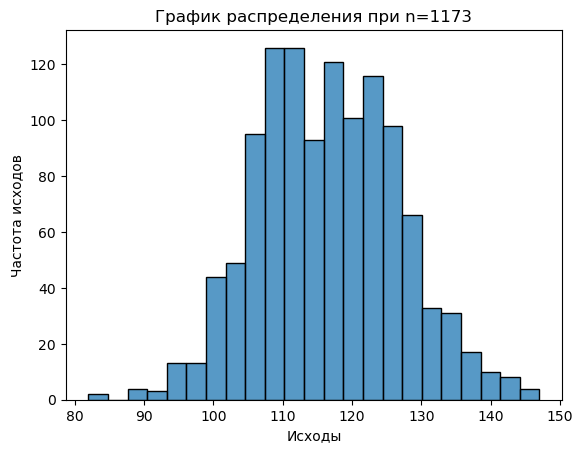

In [124]:
sns.histplot(distr.rvs(1173))
plt.title('График распределения при n=1173')
plt.xlabel("Исходы")
plt.ylabel("Частота исходов")
plt.show()

Таким образом, необходимо разослать промокоды 1173 пользователям, чтобы вероятность того, что подписку продлят менее 100 пользователей составляла примерно 5%.

##### Отдел маркетинга рассылает клиентам push-уведомления в мобильном приложении. Клиенты могут открыть его или не открывать. Известно, что уведомления открывают около 40% получивших клиентов. Отдел планирует разослать 1 млн уведомлений. С помощью аппроксимации построим примерный график распределения и оценим вероятность того, что уведомление откроют не более 399,5 тыс. пользователей.

В данном биномиальном распределении достаточно большое n и p близка к 0.5, поэтому его можно аппроксимировать нормальным. Зададим параметры распределения:

In [128]:
n = 1000000
p = .4
mu = n * p
sigma = (n * p * (1-p)) ** 0.5
distr = st.norm(mu, sigma)

Построим график распределения:

C:\Users\Gleb\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


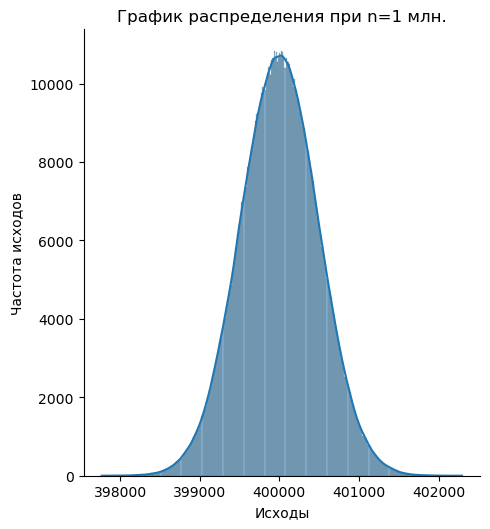

In [130]:
sns.displot(distr.rvs(1000000), kde=True)
plt.title('График распределения при n=1 млн.')
plt.xlabel("Исходы")
plt.ylabel("Частота исходов")
plt.show()

Найдем вероятность того, что уведомление откроют не более 399,5 тыс. пользователей:

In [132]:
distr.cdf(399500)

0.15371708296369768

С вероятностью 15.37% уведомление откроют менее 399,5 тыс. пользователей.

Целью проекта был анализ данных сервиса GoFast и проверка некоторыех гипотезы, которые могут помочь бизнесу вырасти. После предобработки был произведен исследовательский анализ данных и получены следующие выводы:
- Больше всего пользователей из Пятигорска, меньше всего - из Москвы
- Практически у половины пользователей (46%) есть подписка
- Распределение пользователей по возрасту имеет форму близкую к нормальному распределению со средним значением 25 лет, 75% пользователей младше 28 лет и 25% пользователей младше 22 лет
- Большинство пользователей в среднем за поездку проезжают от 2.8 до 3.3 км, 75% поездок меньше 3.776 км
- Большинство пользователей совершают поездку за время от 10 до 25 минут, 77% поездок укладываются в 22 минуты

Далее было произведено удаление выбросов. Для их определения была посчитана средняя скорость поездки, сессии с аномально высокой скоростью были удалены. Потом был создан общий датафрейм с полной информацие о пользователях и разделен по типу подписки и визуализирована информация по расстоянию и времени поездок для этих групп:
- Распределения расстояний имеют похожую форму, однако, у пользователей с подпиской более выражено среднее значение в 3 км и меньший разброс вокруг него
- Распределения по времени практически эдентичны

Затем была подсчитана и записана в отдельный датафрейм помесячная выручка от каждого пользователя.

Далее были проверены ряд гипотез:
- Отвергнута гипотеза о равенстве времени поездок пользователей с подпиской и без в пользу гипотезы о том, что пользователи с подпиской тратят больше времени на поездку, чем пользователи без подписки
- Не была отвергнута нулевая гипотеза о равенстве среднего времени поездки пользователей с подпиской 3130 метрам
- Отвергнута нулевая гипотеза о равенстве помесячной выручки от пользователей с подпиской и без нее в пользу гипотезы о том, что помесячная выручка от пользователей с подпиской больше, чем от пользователей без подписки
- Получили вывод, что необходимо разослать промокоды 1173 пользователям, чтобы вероятность того, что подписку продлят менее 100 пользователей составляла примерно 5% (при вероятности продления 10%)
- С вероятностью 15.37% push-уведомление откроют менее 399,5 тыс. пользователей при рассылке 1 млн. уведомлений.